In [4]:
import string
from pprint import pprint

import nltk
from nltk.corpus import stopwords
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import modules.RNC.rnc_processor as proc
import modules.RNC.rnc_request as req

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\artem\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
image_df = pd.read_csv("modules/data/image_collocations.csv", sep=";")
prestige_df = pd.read_csv("modules/data/prestige_collocations.csv", sep=";")
status_df = pd.read_csv("modules/data/status_collocations.csv", sep=";")

def merge_lexemes(data):
    data["collocation"] = data["lex_1"] + " " + data["lex_2"]

merge_lexemes(image_df)
merge_lexemes(prestige_df)
merge_lexemes(status_df)

image_concordance = req.concordance_json("Имидж")
image_portrait = req.word_portrait_json("Имидж")

prestige_concordance = req.concordance_json("Престиж")
prestige_portrait = req.word_portrait_json("Престиж")

status_concordance = req.concordance_json("Статус")
status_portrait = req.word_portrait_json("Статус")

C:\Users\artem\AppData\Local\Temp\ipykernel_20944\2757323993.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Слово', y='IPM', data=pd.DataFrame(ipm_data).sort_values(by="IPM"), palette='light:b')


<Axes: xlabel='Слово', ylabel='IPM'>

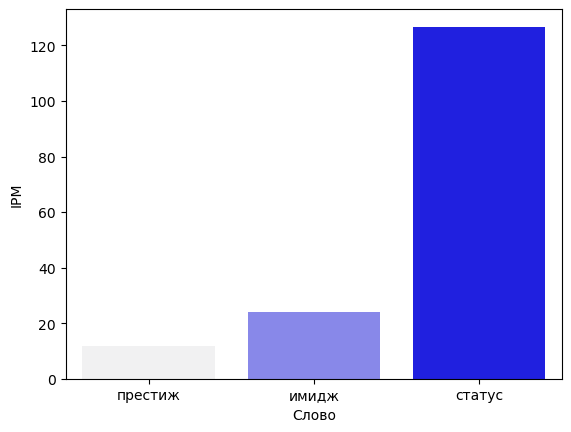

In [ ]:
ipm_data = {
    "Слово": ["имидж", "престиж", "статус"],
    "IPM": [
        proc.get_ipm(image_concordance),
        proc.get_ipm(prestige_concordance),
        proc.get_ipm(status_concordance)
    ]
}

sns.barplot(x="Слово", y="IPM", data=pd.DataFrame(ipm_data).sort_values(by="IPM"), palette="light:b")


C:\Users\artem\AppData\Local\Temp\ipykernel_20944\76355584.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\artem\AppData\Local\Temp\ipykernel_20944\76355584.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\artem\AppData\Local\Temp\ipykernel_20944\76355584.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\artem\AppData\Local\Temp\ipykernel_20944\76355584.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and 

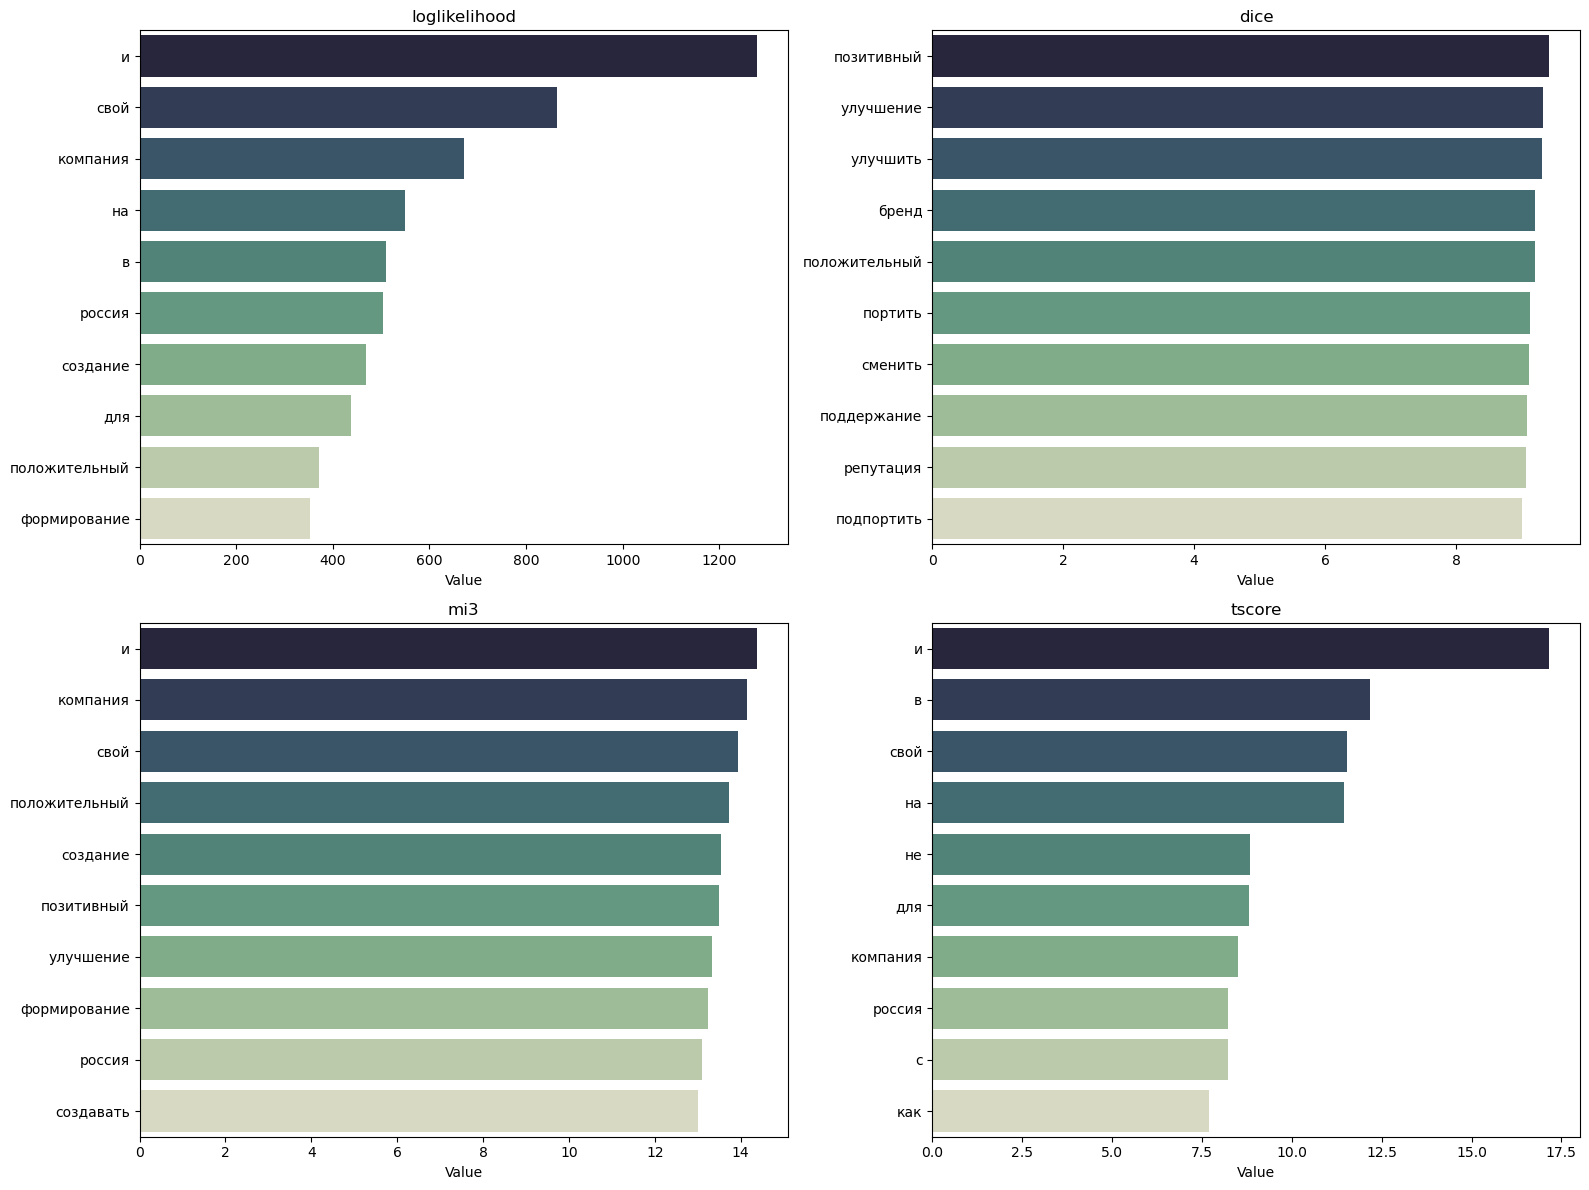

In [195]:
def show_top_collocates(df: pd.DataFrame):

    metrics = ["loglikelihood", "dice", "mi3", "tscore"]
    _, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):

        top_words = df.sort_values(by=metric, ascending=False).head(10)

        sns.barplot(
            x=metric,
            y="lex_2",
            data=top_words,
            palette="ch:start=.3,rot=-.7_r",
            ax=axes[i]
        )
        axes[i].set_title(metric)
        axes[i].set_ylabel("")
        axes[i].set_xlabel("Value")

    plt.tight_layout()
    plt.show()

show_top_collocates(image_df)

In [ ]:
def get_common_collocates(*dfs, top_n=20) -> dict[list]:

    common_collocates = {}

    metrics = ["loglikelihood", "dice", "mi3", "tscore"]
    for metric in metrics:
        top_sets = []
        for df in dfs:
            top_words = df.sort_values(by=metric, ascending=False).head(top_n)
            top_sets.append(set(top_words["lex_2"]))

        common_collocates[metric] = list(set.intersection(*top_sets))

    return common_collocates

top_n = 50

common_presitge_status = get_common_collocates(prestige_df, status_df, top_n=top_n)
common_prestige_image = get_common_collocates(prestige_df, image_df, top_n=top_n)
common_status_image = get_common_collocates(status_df, image_df, top_n=top_n)
common_all = get_common_collocates(prestige_df, image_df, status_df, top_n=top_n)

pprint(common_all)

# print(*list(prestige_df.sort_values(by="tscore", ascending=False).head(top_n)["lex_2"]),sep="\n")


{'dice': [],
 'loglikelihood': ['и',
                   'международный',
                   'который',
                   'по',
                   'его',
                   'на',
                   'свой',
                   'не',
                   'в'],
 'mi3': ['и', 'по', 'свой', 'не', 'в'],
 'tscore': ['этот',
            'с',
            'страна',
            'о',
            'и',
            'россия',
            'который',
            'как',
            'по',
            'для',
            'российский',
            'а',
            'быть',
            'не',
            'его',
            'свой',
            'на',
            'за',
            'что',
            'в']}


In [ ]:
print("Имидж:", proc.get_semantic_labels(image_portrait))
print("Статус:", proc.get_semantic_labels(status_portrait))
print("Престиж:", proc.get_semantic_labels(prestige_portrait))

Имидж: ['r:abstr']
Статус: ['r:abstr']
Престиж: ['ev:posit', 'r:abstr']


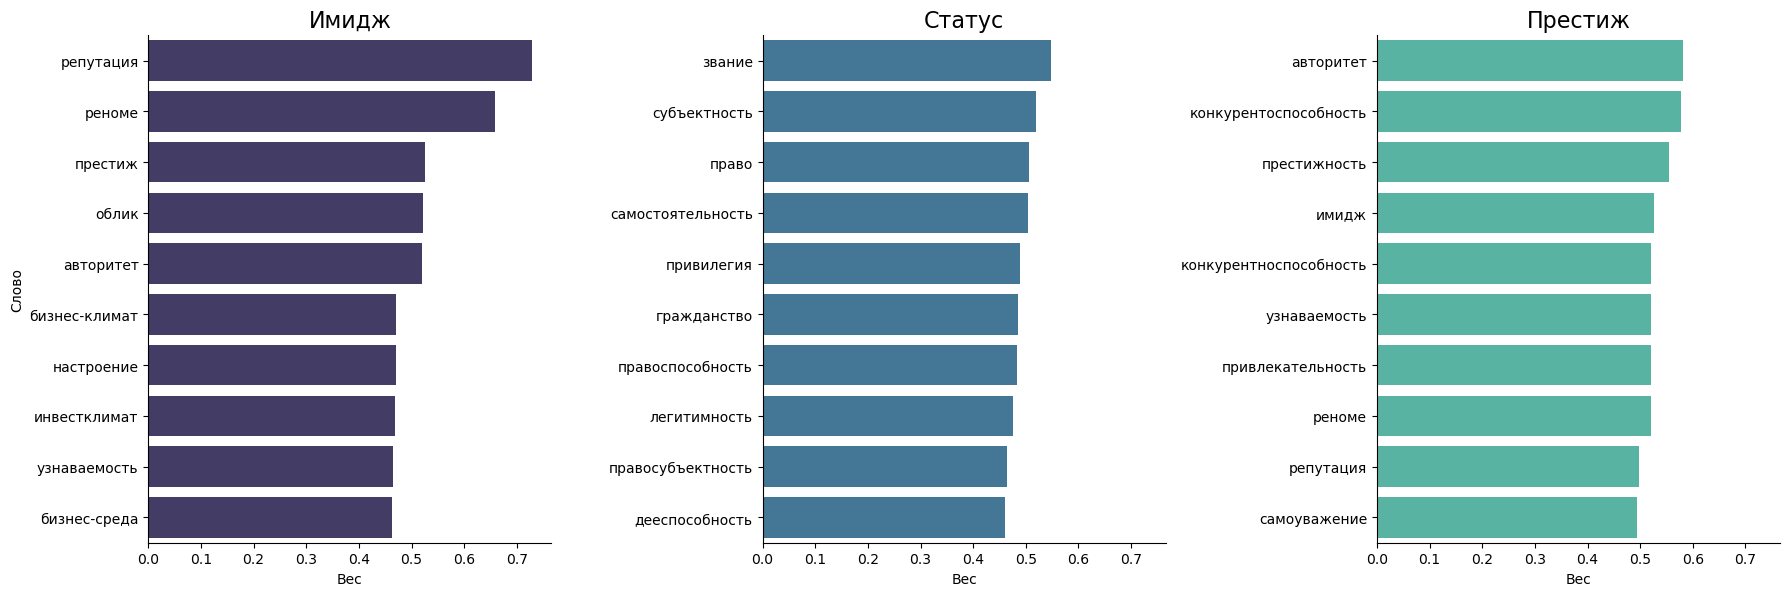

In [164]:
portraits = {
    'Имидж': image_portrait,
    'Статус': status_portrait,
    'Престиж': prestige_portrait
}

similar_data = []

for label, portrait in portraits.items():
    words_weights = proc.get_similar_words(portrait, top_n=10)
    for word, weight in words_weights:
        similar_data.append({
            'Слово': word,
            'Вес': weight,
            'Понятие': label
        })

grid = sns.FacetGrid(pd.DataFrame(similar_data), col="Понятие", height=6,
                  sharey=False, hue="Понятие", palette="mako")

grid.map_dataframe(sns.barplot, x="Вес", y="Слово")

grid.set_titles("{col_name}", size=16)
plt.show()

In [198]:
import pandas as pd

labels = {
    "amod_S_A": "Прилагательные определения",
    "obj_S_V": "Объект/Прямое дополнение",
    "nsubj_S_V": "Субъект/Роль подлежащего",
    "iobj_S_V": "Косв. объект",
    "obl_S_V": "Обстоятельство",
    "conj_S_S": "Однородные",
}

portraits = {
    "Имидж": image_portrait,
    "Статус": status_portrait,
    "Престиж": prestige_portrait
}

sketches = {name: proc.get_word_sketch(portrait) for name, portrait in portraits.items()}

portraits_df = pd.DataFrame({
    name: [", ".join([word for word, _ in sketch.get(label)[:5]])
           for label in labels.keys()]
    for name, sketch in sketches.items()
})

portraits_df.index = list(labels.values())

portraits_df

,Имидж,Статус,Престиж
Прилагательные определения,"позитивный, положительный, сценический, благоприятный, негативный","особый, правовой, нейтральный, внеблоковый, адвокатский","былой, невысокий, международный, высочайший, низкий"
Объект/Прямое дополнение,"подпортить, портить, улучшить, подправить, испортить","придать, присвоить, закрепить, обрести, получить","ронять, подрывать, поднять, уронить, поднимать"
Субъект/Роль подлежащего,"закрепиться, улучшиться, потускнеть, сформироваться, поблекнуть","обязывать, закрепиться, позволять, сохраняться, давать","пошатнуться, падать, повышаться, упасть, повыситься"
Косв. объект,"вредить, повредить, навредить, наносить, нанести","лишить, наделить, наделять, лишиться, лишать","наносить, повредить, нанести, дорожить, навредить"
Обстоятельство,"сказываться, сказаться, отразиться, вязаться, отражаться","претендовать, приравнять, пребывать, приравнеть, перевести","откачать, радеть, ударить, сказываться, наплевать"
Однородные,"имидж, репутация, престиж, привлекательность, авторитет","статус, амнистия, полномочие, положение, льгота","привлекательность, авторитет, престиж, имидж, значимость"


C:\Users\artem\AppData\Local\Temp\ipykernel_16700\1722996316.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(data.keys()), y=list(data.values()), palette="ch:s=-.2,r=.6")


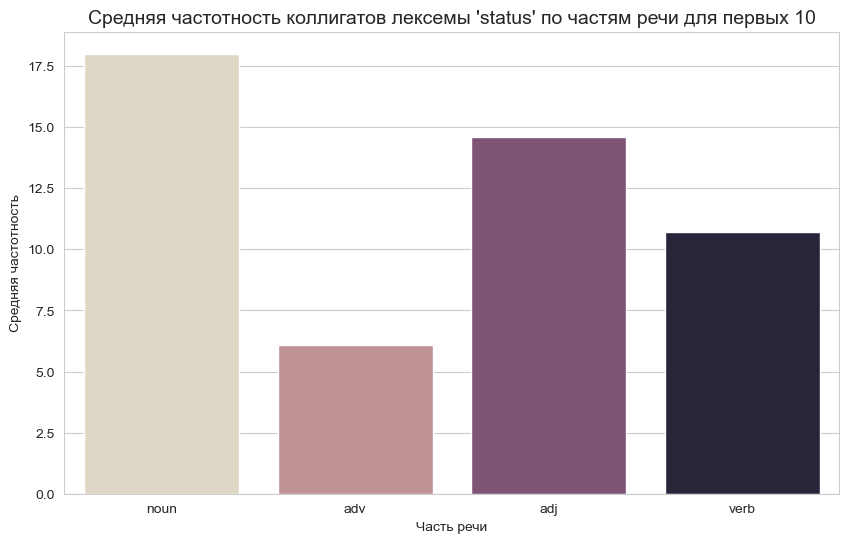

C:\Users\artem\AppData\Local\Temp\ipykernel_16700\1722996316.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(data.keys()), y=list(data.values()), palette="ch:s=-.2,r=.6")


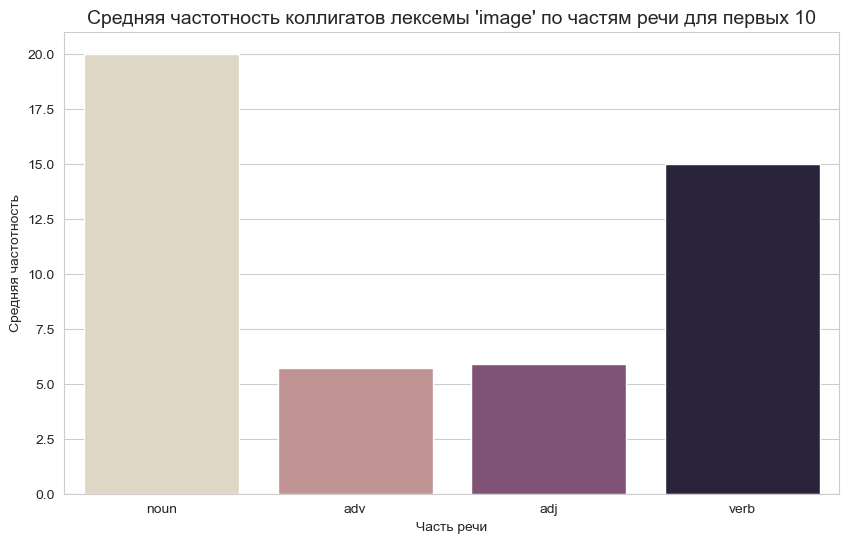

C:\Users\artem\AppData\Local\Temp\ipykernel_16700\1722996316.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(data.keys()), y=list(data.values()), palette="ch:s=-.2,r=.6")


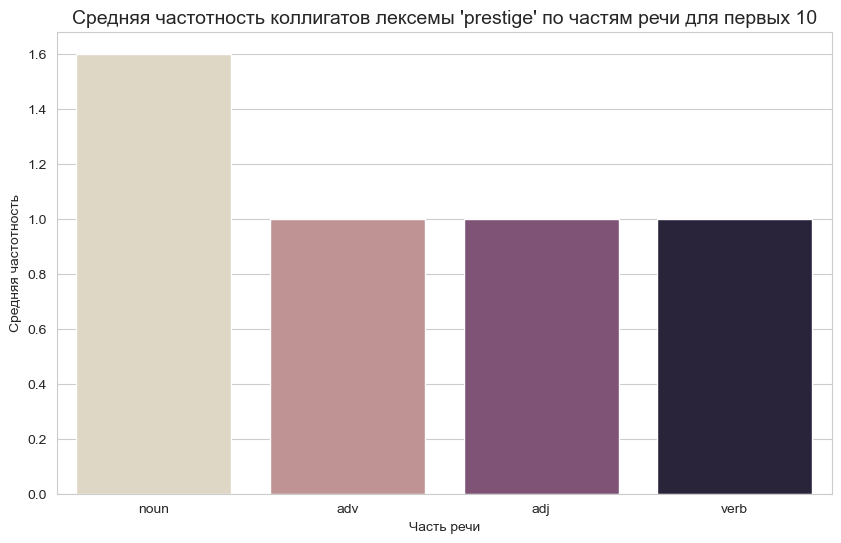

In [23]:
part_of_speech = ["noun", "adv", "adj", "verb"]
corpus = ["bnc", "coca"]
top_n = 10

words = ["status", "image", "prestige"]

def frequencies_mean(word: str, corpus: str, top_n: int = 20):

    labels = {}
    for part in part_of_speech:
        file_name = f"modules/data/{corpus}_{word}_colligations_{part}.xlsx"

        try:
            df = pd.read_excel(file_name)
            labels[part] = df.iloc[:top_n, 4].mean()
        except:
            print(f"{file_name} not found")

    return labels

def visualise_mean(word: str, data: dict):
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(x=list(data.keys()), y=list(data.values()), palette="ch:s=-.2,r=.6")

    plt.title(f"Средняя частотность коллигатов лексемы '{word}' по частям речи для первых {top_n}", fontsize=14)
    plt.ylabel("Средняя частотность")
    plt.xlabel("Часть речи")
    plt.show()

for word in words:
    visualise_mean(word, frequencies_mean(word, corpus[1], top_n=top_n))





C:\Users\artem\AppData\Local\Temp\ipykernel_24564\1722996316.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(data.keys()), y=list(data.values()), palette="ch:s=-.2,r=.6")


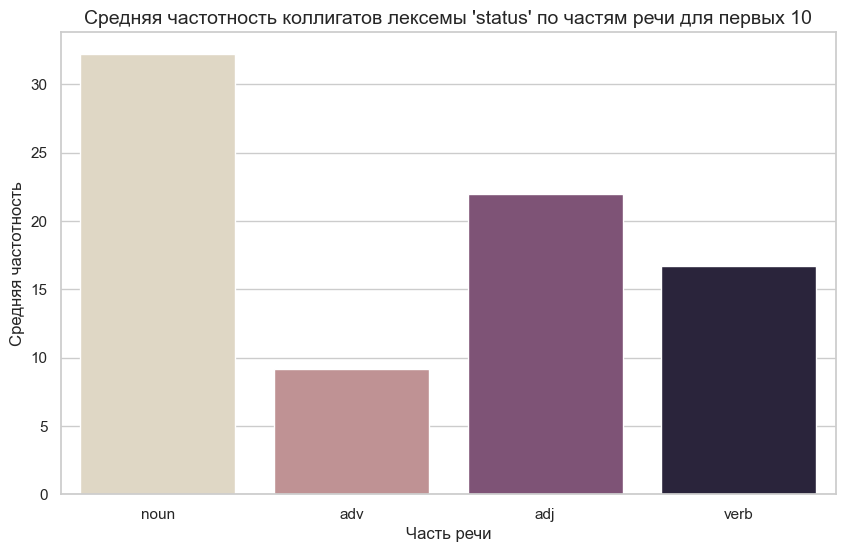

C:\Users\artem\AppData\Local\Temp\ipykernel_24564\1722996316.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(data.keys()), y=list(data.values()), palette="ch:s=-.2,r=.6")


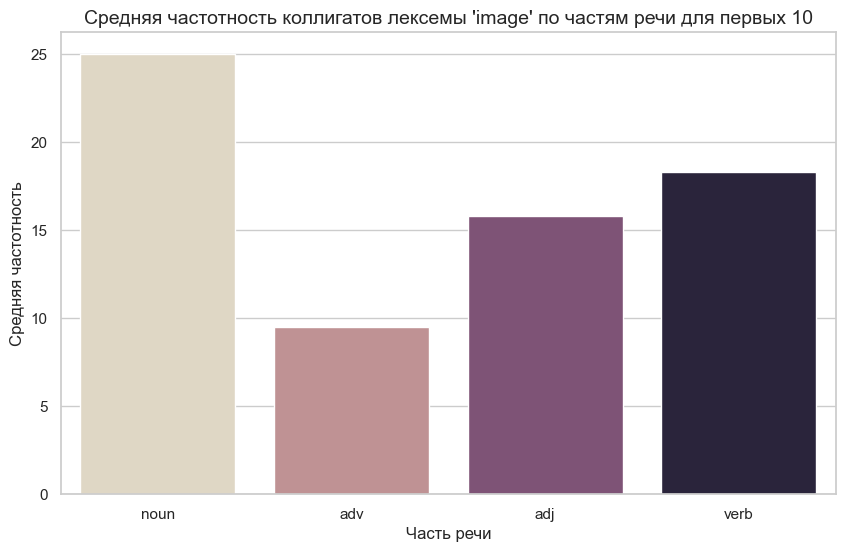

C:\Users\artem\AppData\Local\Temp\ipykernel_24564\1722996316.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(data.keys()), y=list(data.values()), palette="ch:s=-.2,r=.6")


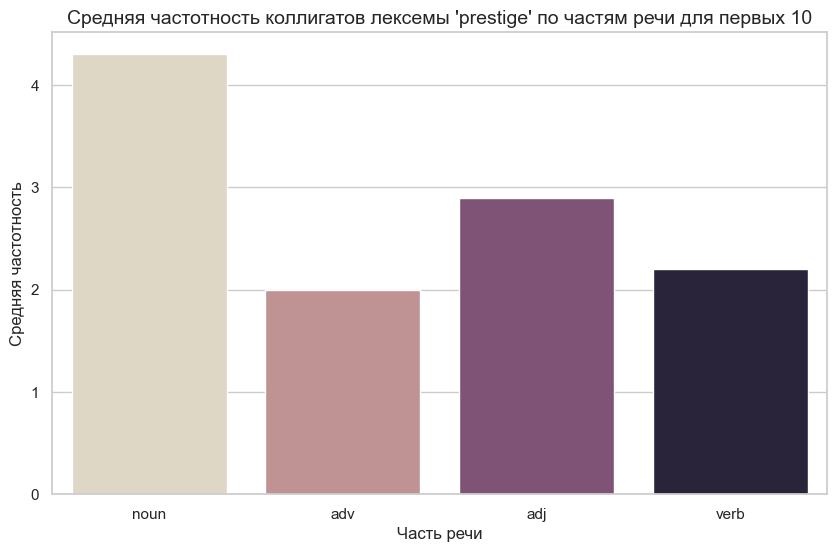

In [55]:
for word in words:
    coca_mean = frequencies_mean(word, corpus[1], top_n=top_n)
    bnc_mean = frequencies_mean(word, corpus[0], top_n=top_n)
    labels = {}
    for part in part_of_speech:
        labels[part] = coca_mean[part] + bnc_mean[part]
    visualise_mean(word, labels)

C:\Users\artem\AppData\Local\Temp\ipykernel_24564\1722996316.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(data.keys()), y=list(data.values()), palette="ch:s=-.2,r=.6")


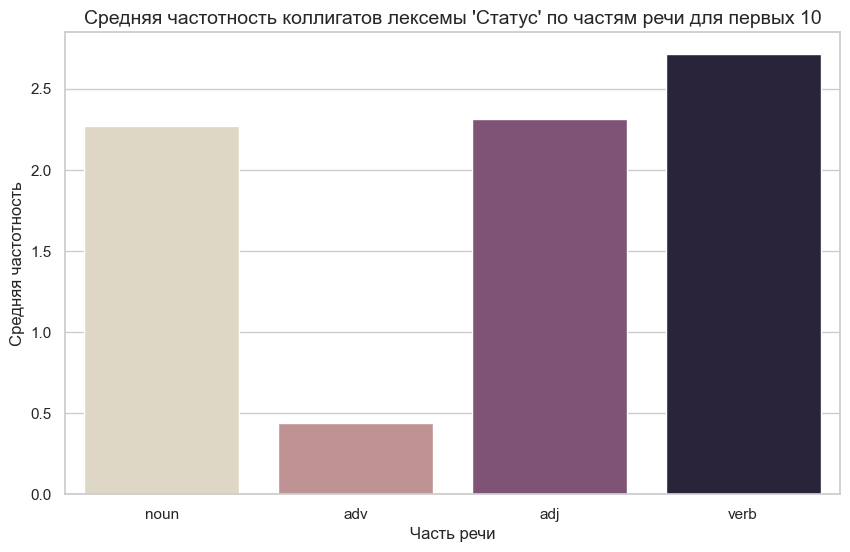

C:\Users\artem\AppData\Local\Temp\ipykernel_24564\1722996316.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(data.keys()), y=list(data.values()), palette="ch:s=-.2,r=.6")


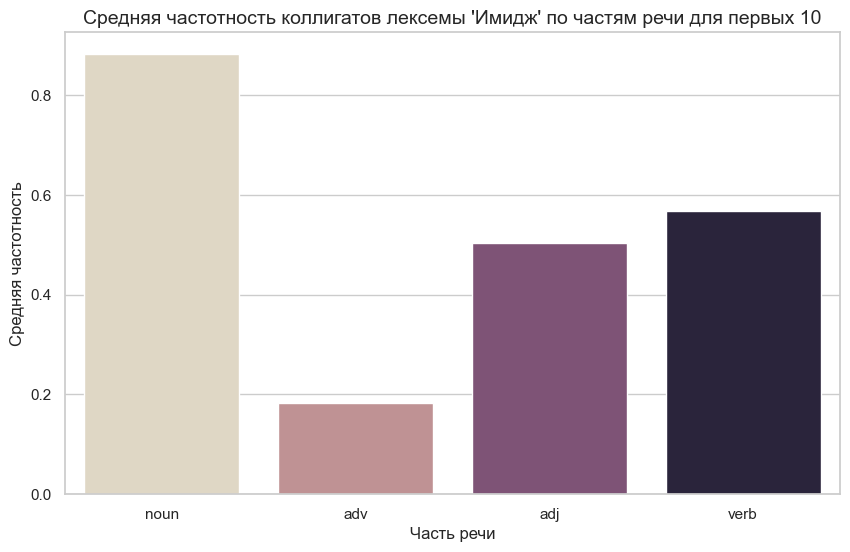

C:\Users\artem\AppData\Local\Temp\ipykernel_24564\1722996316.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(data.keys()), y=list(data.values()), palette="ch:s=-.2,r=.6")


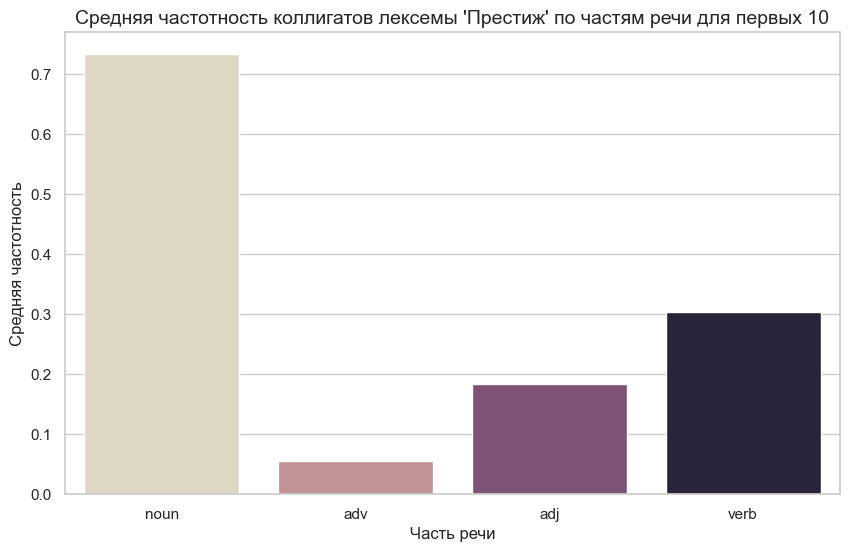

In [52]:
def frequencies_mean_rnc(word: str, top_n: int = 20):
    labels = {}

    for part in part_of_speech:
        file_name = f"modules/data/rnc_{word}_colligations_{part}.xlsx"
        try:
            df = pd.read_excel(file_name)
        except:
            print(f"{file_name} not found")
            return

        df = df.groupby('word_1').agg({
            'ipm': 'sum',
            'hits': 'sum'
        }).reset_index()

        labels[part] = df.sort_values(by='ipm', ascending=False).head(10)['ipm'].mean()

    return labels


visualise_mean("Статус", frequencies_mean_rnc("status"))
visualise_mean("Имидж", frequencies_mean_rnc("image"))
visualise_mean("Престиж", frequencies_mean_rnc("prestige"))


C:\Users\artem\AppData\Local\Temp\ipykernel_16700\2993868727.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


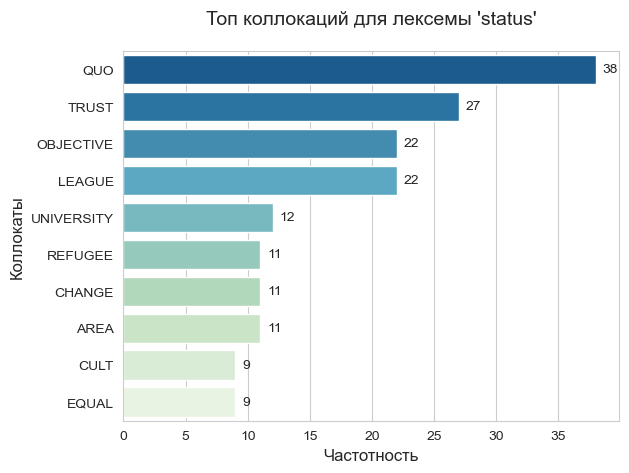

C:\Users\artem\AppData\Local\Temp\ipykernel_16700\2993868727.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


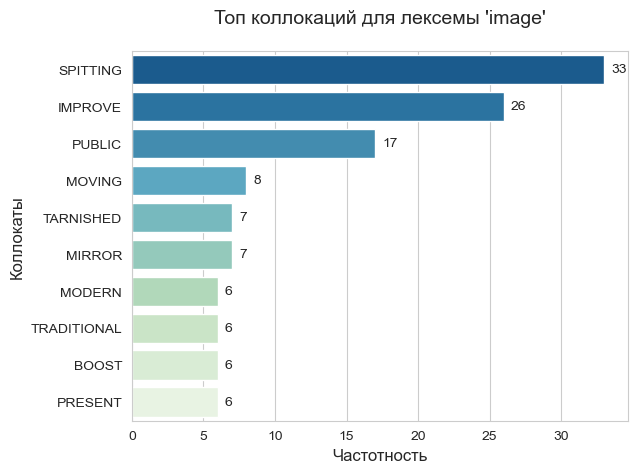

C:\Users\artem\AppData\Local\Temp\ipykernel_16700\2993868727.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


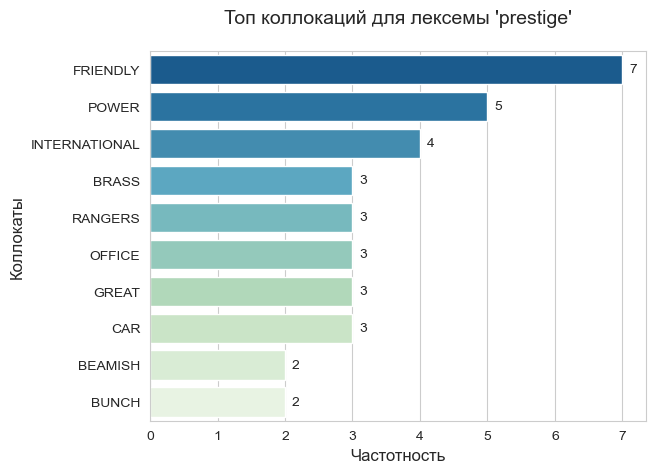

In [28]:
stop_words = set(stopwords.words("english"))


def clean_collocations(file_path, top_n=20):
    df = pd.read_excel(file_path)

    col_name = 'RE-USE WORDS'

    def _is_valid(word):
        if pd.isna(word):
            return False

        normalized = str(word).lower().strip()
        if normalized in stop_words or normalized in string.punctuation:
            return False

        if  len(normalized) < 2 or normalized.isdigit():
            return False

        return True

    df_clean = df[df[df.columns[3]].apply(_is_valid)].copy()

    df_clean = df_clean.sort_values(by=df.columns[4], ascending=False)

    return df_clean.head(top_n)[[df.columns[3], df.columns[4]]]



def plot_top_collocations(df, title, top_n=20):
    ax = sns.barplot(
        x='FREQ',
        y='RE-USE WORDS',
        data=df.head(top_n),
        palette='GnBu_r'
    )

    plt.title(title, fontsize=14, pad=20)
    plt.xlabel("Частотность", fontsize=12)
    plt.ylabel("Коллокаты", fontsize=12)

    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}',
                    (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0),
                    textcoords='offset points')

    plt.show()

for word in words:
    file_name = f"modules/data/{corpus[0]}_{word}_collocations.xlsx"
    plot_top_collocations(clean_collocations(file_name), f"Топ коллокаций для лексемы '{word}'", top_n=10)